In [35]:
# !pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn pandas matplotlib
from bertopic import BERTopic
import pandas as pd

In [3]:
import torch
print("GPU Available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

GPU Available: True


In [124]:
data = pd.read_csv('highconf_label_data.csv')

cat = 2.0

data = data[data['label'] == cat]
data = data.dropna(subset=['body']).reset_index(drop=True)

data = data['body'].to_list()

In [125]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(min_cluster_size=20,  # min cluster size before it can become its own
                        min_samples=15,       # how many neighbors it has before its part of a clsuter
                        cluster_selection_epsilon=0.1,
                        metric="euclidean",
                        prediction_data=True)

In [139]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
topic_model = BERTopic(embedding_model=embedding_model,
                       hdbscan_model=hdbscan_model,
                       vectorizer_model=vectorizer_model,
                       verbose=True)
topics, probs = topic_model.fit_transform(data)

2025-03-15 14:08:51,098 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/336 [00:00<?, ?it/s]

2025-03-15 14:08:59,824 - BERTopic - Embedding - Completed ✓
2025-03-15 14:08:59,825 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-15 14:09:07,179 - BERTopic - Dimensionality - Completed ✓
2025-03-15 14:09:07,181 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-15 14:09:07,670 - BERTopic - Cluster - Completed ✓
2025-03-15 14:09:07,676 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-03-15 14:09:08,694 - BERTopic - Representation - Completed ✓


In [127]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [140]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3946,-1_life_human_abortion_baby,"[life, human, abortion, baby, child, unborn, m...","[there is no right to kill a baby., well you w..."
1,0,959,0_murder_innocent_killing_murder murder,"[murder, innocent, killing, murder murder, kil...","[(it was always murder), its murder., it's mur..."
2,1,739,1_babies_killing babies_killing_baby,"[babies, killing babies, killing, baby, kill b...","[...by not killing babies?..., who's killing b..."
3,2,619,2_pro_life_abortion_human,"[pro, life, abortion, human, pro life, child, ...",[i'm sure most pro-choice people you come acro...
4,3,399,3_vote_democrats_court_trump,"[vote, democrats, court, trump, election, like...",[this is like 80% of the reason biden's approv...
5,4,313,4_link_lol_said_la,"[link, lol, said, la, la la, read, thank, oh, ...","[link, link, link]"
6,5,275,5_baby_baby baby_babies_babies baby,"[baby, baby baby, babies, babies baby, baby ba...","[and the baby?, what baby?, a baby is a baby i..."
7,6,256,6_rape_child_incest_baby,"[rape, child, incest, baby, raped, rapist, lif...","[no, that is not what i said. reread it. i cle..."
8,7,204,7_children_child_innocent_innocent children,"[children, child, innocent, innocent children,...","[child murder, what do you call the murder of ..."
9,8,175,8_shes_killed_baby_did,"[shes, killed, baby, did, killing, killed baby...",[they want at her. they want to save her by t...


In [141]:
topic_labels = topic_model.get_topic_info()

In [142]:
general_abort = [data[i] for i, topic in enumerate(topics) if topic == -1]

for i, doc in enumerate(general_abort[:10]):
  print(f'{i}:: {doc}')
  print("")

0:: actually, it's about money. we have a record deficit, and they want to cut everything that is not necessary. if pp is so important to women's  health, then shouldn't that be paid for from obama's health care plan instead?

1:: there are many logical arguments for abortion. bodily autonomy is not one of them.  a woman's claim to bodily autonomy (in cases of "accidental" pregnancy as a result of consensual sexual) is mitigated by the fact that she consented to an act whose fundamental consequence is pregnancy.   it would be illogical and cruel to invite you over to my home, then arbitrarily declare you an intruder and force you out.

2:: pretty much all laws tell you what you can do with your body.  the unborn also have bodily autonomy, just like a 1 day old. like a 1 day old, women have a responsibility to care for that life as best they can.

3:: i effectively refuted how even at its logical extremity, that it in no way captures the dynamic of a pregnant mother. therefore, the anal

this does seem very overarching, but i am curious why it didnt fit into any of the 70 topics identified...

In [144]:
from sklearn.metrics.pairwise import cosine_similarity
topic_embeddings = topic_model.topic_embeddings_
similarity_matrix = cosine_similarity(topic_embeddings)

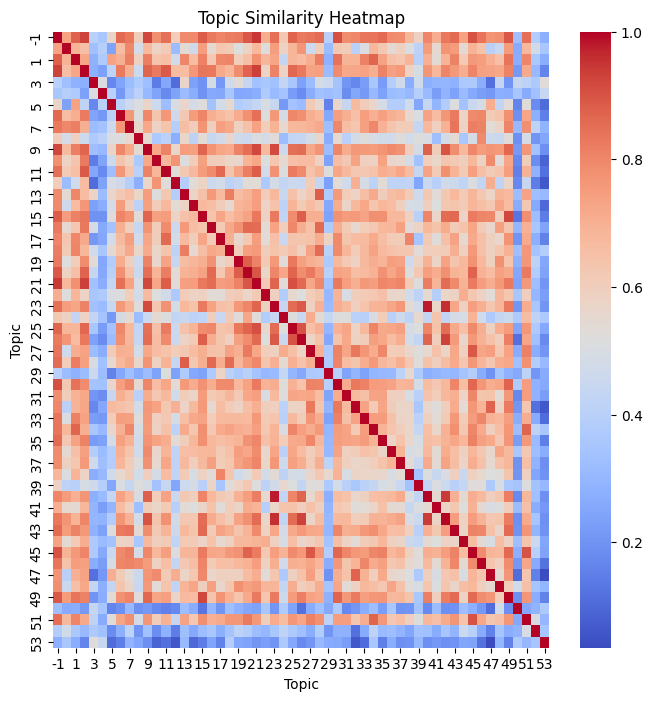

In [145]:
topic_sim_df = pd.DataFrame(similarity_matrix,
                            index=topic_model.get_topic_info()["Topic"],
                            columns=topic_model.get_topic_info()["Topic"])

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.heatmap(topic_sim_df, cmap="coolwarm", annot=False)
plt.title("Topic Similarity Heatmap")
plt.show()


In [146]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

topic_embeddings = topic_model.topic_embeddings_
similarity_matrix = cosine_similarity(topic_embeddings)

topic_sim_df = pd.DataFrame(similarity_matrix)

similar_pairs = set()
for i in range(len(topic_sim_df)):
    for j in range(i + 1, len(topic_sim_df)):
        if similarity_matrix[i, j] > 0.9:
            similar_pairs.add((i, j, similarity_matrix[i, j]))

similar_pairs = sorted(similar_pairs, key=lambda x: x[2], reverse=True)

print(len(similar_pairs))

similar_pairs

17


[(24, 41, 0.9787557),
 (24, 43, 0.95820653),
 (0, 22, 0.94440526),
 (41, 43, 0.9400661),
 (3, 22, 0.93451905),
 (27, 43, 0.9316294),
 (0, 3, 0.931216),
 (0, 10, 0.9241219),
 (10, 22, 0.92308354),
 (16, 50, 0.9222261),
 (10, 24, 0.9192132),
 (22, 26, 0.90852165),
 (0, 31, 0.9071027),
 (46, 52, 0.90520775),
 (0, 46, 0.90411836),
 (26, 27, 0.9028193),
 (10, 43, 0.9015389)]

In [155]:
54 - 17

37

In [153]:
topic_info[topic_info['Topic'] == 3]

,Topic,Count,Name,CustomName,Representation,Representative_Docs
4,3,264,3_abortion_baby_abortions_babies,2_rights_right_autonomy_unborn,"[abortion, baby, abortions, babies, kill, trea...",[original comment said catholic hospital would...


In [154]:
topic_info[topic_info['Topic'] == 22]

,Topic,Count,Name,CustomName,Representation,Representative_Docs
23,22,76,22_abortion murder_murder abortion_abortion_mu...,21_babies_killing babies_support_support killing,"[abortion murder, murder abortion, abortion, m...","[abortion murder, abortion murder, abortion mu..."


In [156]:
topic_model = topic_model.reduce_topics(data, nr_topics=37)

topic_model.get_topic_info()

2025-03-15 14:11:46,706 - BERTopic - Topic reduction - Reducing number of topics
2025-03-15 14:11:47,827 - BERTopic - Topic reduction - Reduced number of topics from 55 to 37


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3946,-1_life_human_abortion_baby,"[life, human, abortion, baby, child, murder, u...","[there is no right to kill a baby., well you w..."
1,0,1281,0_abortion_life_murder_pro,"[abortion, life, murder, pro, human, child, ki...","[abortion is not murder., abortion is murder.,..."
2,1,959,1_murder_innocent_killing_life,"[murder, innocent, killing, life, kill, human,...","[its not murder though, murder., not murder th..."
3,2,787,2_babies_killing babies_killing_baby,"[babies, killing babies, killing, baby, kill, ...","[it is killing babies!, nor is killing babies...."
4,3,399,3_vote_democrats_court_trump,"[vote, democrats, court, trump, election, like...",[this is like 80% of the reason biden's approv...
5,4,313,4_link_lol_said_la,"[link, lol, said, la, la la, like, read, oh, t...","[link, link, link]"
6,5,277,5_abortion_right_conservatives_life,"[abortion, right, conservatives, life, rights,...",[except they were wrong in that case too. here...
7,6,275,6_baby_baby baby_babies_babies baby,"[baby, baby baby, babies, babies baby, baby ba...","[its not a baby., its not a baby, what baby?]"
8,7,261,7_babies_killing babies_killing_democrats,"[babies, killing babies, killing, democrats, l...","[these leftists love killing babies, why do de..."
9,8,256,8_rape_child_baby_life,"[rape, child, baby, life, incest, raped, rapis...",[rape and incest are not the exceptions. if yo...


In [ ]:
labels = {
    -1: 'Less structured abortion discourse'
    0: 'Abortion is Murder',
    1: 'Abortion is Murder',
    2: 'Killing babies',
    3: 'Politics and Voting',
    4: 'Sharing Links',
    5: 'Constitutional Debates and States Rights',
    6: 'Babies ?',
    7: 'Killing Babies (Specifically democrats liking to kill babies)',
    8: 'Exceptions arent exceptions',
    9: 'Innocent children (murder)',
    10: 'Mixed',
    11: 'Murder (fetus)',
    12: 'Defining Human Life',
    13: 'Life Begins at Conception',
    14: 'Right to Life',
    15: 'Personal Responsbility (Pregnancy is consequence)',
    16: 'Religious Opposition (to killing babies)',
    17: 'Healthcare System',
    18: 'Defining Human Life',
    19: 'Rights (Life Liberty Pursuit)'
    20: 'Religion (Cathloic Church)',
    21: 'Killing unborn children',
    22: 'Murder, Extreme Rhetoric?',
    23: 'Adoption',
    24: 'Body Autonomy (PRolife side)',
    25: 'Abortion is Genocide',
    26: 'Murder (Roe is in here)',
    27: 'Religion (Satan)',
    28: 'Womens rights (prolife side, babies have rights)'
    29: 'Abortion and Slavery',
    30: 'Vaccines (body autonomy)',
    31: 'Exceptions arent exceptions',
    32: 'Planned Parenthood',
    33: 'Unrelated (Econonmy)',
    34: 'Guns',
    35: '(Anti) Democrat, Protests',
}

merging:
- murder [0, 1, 2, 7, 9, 11, 21, 26]
- religion [16, 20, 27]
- no excpetions [8, 31]
- begining of life [12, 18, 13]
- right to life [14, 19]
- extreme comparisions (slavery, nazis, genocide) [22, 25, 29]
- body autonomy [24, 28, 30]

In [211]:
rep_docs = topic_model.get_representative_docs()
topic_keywords = topic_model.get_topics()

topic_id = 35

for word in topic_keywords[topic_id]:
  print(word[0])

for comment in rep_docs[topic_id][:5]:
  print(f"- {comment}\n")


dem
audience
protests
dem city
city
protest
dem lawyer
rioters
lawyer
dem rioters
- no.  i'm past giving a fuck about people bitching because a peaceful protest is blocking "muh right to drive". you do not have a right to drive, you have a right to unrestricted movement. still got your legs? fucking use them. no one is restricting your ability to walk.  protests are inconveniencing you? they're preventing you from just doing your job? good. that's what they're supposed to do. cause that's the only way to get people to fucking listen.

- where did i ever say one type of advocacy should be allowed over another? to reiterate: public servants partaking in protests or making political statements while in uniform, whatever the statement may be, is inappropriate. you seem to think id give a pass to the other officers mentioned, which is incorrect.   youre right, audience does matter. and for all intents and purposes, its the same as if he was in a parade like those other officers. why? becaus

Still seems to be sims, but I can merge manually. need to look more at 1.


In [224]:
labels = {
    0: 'Abortion as Murder and Killing',
    1: 'Abortion as Murder and Killing',
    2: 'Abortion as Murder and Killing',
    7: 'Abortion as Murder and Killing',
    9: 'Abortion as Murder and Killing',
    11: 'Abortion as Murder and Killing',
    21: 'Abortion as Murder and Killing',
    26: 'Abortion as Murder and Killing',

    16: 'Religious Opposition to Abortion',
    20: 'Religious Opposition to Abortion',
    27: 'Religious Opposition to Abortion',

    8: 'No Exceptions for Abortion (Rape, Incest, etc.)',
    31: 'No Exceptions for Abortion (Rape, Incest, etc.)',

    12: 'Defining Human Life in Abortion Debate',
    18: 'Defining Human Life in Abortion Debate',
    13: 'Defining Human Life in Abortion Debate',

    14: 'Right to Life and Anti-Abortion Stance',
    19: 'Right to Life and Anti-Abortion Stance',

    22: 'Abortion as Genocide and Extreme Comparisons',
    25: 'Abortion as Genocide and Extreme Comparisons',
    29: 'Abortion as Genocide and Extreme Comparisons',

    24: 'Bodily Autonomy in the Pro-Life Debate',
    28: 'Bodily Autonomy in the Pro-Life Debate',
    30: 'Bodily Autonomy in the Pro-Life Debate',

    # Unmerged topics
    3: 'Political Views on Abortion and Voting',
    4: 'Sharing Links and Informational Resources',
    5: 'Constitutional Rights and States’ Rights in Abortion Debate',
    6: 'Uncertainty Around the Definition of Babies and Abortion',
    10: 'Mixed Views on Abortion and Related Issues',
    17: 'Healthcare System',
    23: 'Adoption as an Alternative to Abortion',
    33: 'Unrelated Topics (Economy, General Issues)',
    32: 'Planned Parenthood',
    34: 'Guns',
    35: 'Anti-Democrat Views and Protests'
}

topic_model.set_topic_labels(labels)


In [225]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,3946,-1_life_human_abortion_baby,-1_life_human_abortion_baby,"[life, human, abortion, baby, child, murder, u...","[there is no right to kill a baby., well you w..."
1,0,1281,0_abortion_life_murder_pro,Abortion as Murder and Killing,"[abortion, life, murder, pro, human, child, ki...","[abortion is not murder., abortion is murder.,..."
2,1,959,1_murder_innocent_killing_life,Abortion as Murder and Killing,"[murder, innocent, killing, life, kill, human,...","[its not murder though, murder., not murder th..."
3,2,787,2_babies_killing babies_killing_baby,Abortion as Murder and Killing,"[babies, killing babies, killing, baby, kill, ...","[it is killing babies!, nor is killing babies...."
4,3,399,3_vote_democrats_court_trump,Political Views on Abortion and Voting,"[vote, democrats, court, trump, election, like...",[this is like 80% of the reason biden's approv...
5,4,313,4_link_lol_said_la,Sharing Links and Informational Resources,"[link, lol, said, la, la la, like, read, oh, t...","[link, link, link]"
6,5,277,5_abortion_right_conservatives_life,Constitutional Rights and States’ Rights in Ab...,"[abortion, right, conservatives, life, rights,...",[except they were wrong in that case too. here...
7,6,275,6_baby_baby baby_babies_babies baby,Uncertainty Around the Definition of Babies an...,"[baby, baby baby, babies, babies baby, baby ba...","[its not a baby., its not a baby, what baby?]"
8,7,261,7_babies_killing babies_killing_democrats,Abortion as Murder and Killing,"[babies, killing babies, killing, democrats, l...","[these leftists love killing babies, why do de..."
9,8,256,8_rape_child_baby_life,"No Exceptions for Abortion (Rape, Incest, etc.)","[rape, child, baby, life, incest, raped, rapis...",[rape and incest are not the exceptions. if yo...


In [243]:
topics_to_merge = [
    [0, 1, 2, 7, 9, 11, 21, 26],
    [16, 20, 27],
    [8, 31],
    [12, 18, 13],
    [14, 19],
    [22, 25, 29],
    [24, 28, 30]
]

topic_model.merge_topics(data, topics_to_merge)

topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3946,-1_life_human_abortion_baby,"[life, human, abortion, baby, murder, child, u...","[there is no right to kill a baby., well you w..."
1,0,3751,0_murder_killing_abortion_life,"[murder, killing, abortion, life, kill, babies...","[not murder them?, its murder, now do murder]"
2,1,399,1_vote_democrats_court_trump,"[vote, democrats, court, trump, like, people, ...","[as you know, that's not the test for whether ..."
3,2,343,2_human_life_conception_begins,"[human, life, conception, begins, life begins,...","[life begins at conception., life begins at co..."
4,3,313,3_link_lol_said_like,"[link, lol, said, like, la, just, read, oh, la...","[link, link, link]"
5,4,284,4_rape_child_baby_life,"[rape, child, baby, life, incest, innocent, ra...","[if you want to make a triage argument, i doub..."
6,5,277,5_abortion_right_life_conservatives,"[abortion, right, life, conservatives, rights,...","[jrme lejeune, a french geneticist and discove..."
7,6,275,6_baby_baby baby_babies_babies baby,"[baby, baby baby, babies, babies baby, baby ba...","[it's not a baby., then when is it a baby?, it..."
8,7,200,7_god_religion_church_babies,"[god, religion, church, babies, satan, killing...","[so, is their a separation between church and ..."
9,8,191,8_right_right life_rights_life,"[right, right life, rights, life, unborn, libe...",[do unborn children not have the right to life...


In [251]:
rep_docs = topic_model.get_representative_docs()
topic_keywords = topic_model.get_topics()

topic_id = 10

for word in topic_keywords[topic_id]:
  print(word[0])

for comment in rep_docs[topic_id][:5]:
  print(f"- {comment}\n")


control unborn
cares laws
logic lived
fuck cares
body fuck
lived nazi
germany quit
agree use
undeniably murder
country agree
- it's undeniably murder. unborn babies have the same right to life as you and i. you don't have a right to control an unborn baby's body. who the fuck cares if the "laws of this country" agree with you, would you use that same logic if you lived in nazi germany? quit while you're behind.

- it's undeniably murder. unborn babies have the same right to life as you and i. you don't have a right to control an unborn baby's body. who the fuck cares if the "laws of this country" agree with you, would you use that same logic if you lived in nazi germany? quit while you're behind.

- it's undeniably murder. unborn babies have the same right to life as you and i. you don't have a right to control an unborn baby's body. who the fuck cares if the "laws of this country" agree with you, would you use that same logic if you lived in nazi germany? quit while you're behind.



In [252]:
labels = {
    0: 'Abortion as Murder and Killing',
    1: 'Political Views and Voting',
    2: 'Defining Human Life (Life Begins at Conception)',
    3: 'Sharing Links',
    4: 'No Exceptions for Abortion (Rape, Incest, etc.)',
    5: 'Right to Life',
    6: 'Babies ?',
    7: 'Religious Opposition to Abortion',
    8: 'Mixed, speaking about women',
    9: 'Abortion as Genocide and Extreme Comparisons',
    10: 'Bodily Autonomy in the Pro-Life Debate',
    11: 'Personal Responsibility',
    12: 'Healthcare',
    13: 'Adoption as an Alternative to Abortion',
    14: 'Planned Parenthood',
    15: 'Unrelated Topics (Economy, General Issues)',
    16: 'Guns',
    17: 'Anti-Democrat Views and Protests',
}



topic_model.set_topic_labels(labels)

topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,3946,-1_life_human_abortion_baby,-1_life_human_abortion_baby,"[life, human, abortion, baby, murder, child, u...","[there is no right to kill a baby., well you w..."
1,0,3751,0_murder_killing_abortion_life,Abortion as Murder and Killing,"[murder, killing, abortion, life, kill, babies...","[not murder them?, its murder, now do murder]"
2,1,399,1_vote_democrats_court_trump,Political Views and Voting,"[vote, democrats, court, trump, like, people, ...","[as you know, that's not the test for whether ..."
3,2,343,2_human_life_conception_begins,Defining Human Life (Life Begins at Conception),"[human, life, conception, begins, life begins,...","[life begins at conception., life begins at co..."
4,3,313,3_link_lol_said_like,Sharing Links,"[link, lol, said, like, la, just, read, oh, la...","[link, link, link]"
5,4,284,4_rape_child_baby_life,"No Exceptions for Abortion (Rape, Incest, etc.)","[rape, child, baby, life, incest, innocent, ra...","[if you want to make a triage argument, i doub..."
6,5,277,5_abortion_right_life_conservatives,Right to Life,"[abortion, right, life, conservatives, rights,...","[jrme lejeune, a french geneticist and discove..."
7,6,275,6_baby_baby baby_babies_babies baby,Babies ?,"[baby, baby baby, babies, babies baby, baby ba...","[it's not a baby., then when is it a baby?, it..."
8,7,200,7_god_religion_church_babies,Religious Opposition to Abortion,"[god, religion, church, babies, satan, killing...","[so, is their a separation between church and ..."
9,8,191,8_right_right life_rights_life,"Mixed, speaking about women","[right, right life, rights, life, unborn, libe...",[do unborn children not have the right to life...


In [280]:
from google.colab import drive
drive.mount('/content/drive')

topic_model.save('/content/drive/MyDrive/prolife_berttopic')

2025-03-15 15:58:31,245 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [254]:
topic_model.visualize_topics()


In [255]:
topic_model.visualize_barchart()


In [260]:
!pip install gensim


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 29.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [264]:
topics = topic_model.get_topics()
topics

{-1: [('life', 0.019478140435384393),
  ('human', 0.016127085270898154),
  ('abortion', 0.01589752450630951),
  ('baby', 0.015598697965096098),
  ('murder', 0.01466194250809659),
  ('child', 0.014486447476012618),
  ('unborn', 0.01347653181815845),
  ('right', 0.012786365519712864),
  ('killing', 0.012761724731679277),
  ('kill', 0.011285552253016895)],
 0: [('murder', 0.02928817724109632),
  ('killing', 0.022830023042850808),
  ('abortion', 0.02111195799840167),
  ('life', 0.021067593357772314),
  ('kill', 0.01621312075933929),
  ('babies', 0.016168658806331258),
  ('human', 0.015430912777969878),
  ('baby', 0.01511442569457882),
  ('innocent', 0.01454130667294717),
  ('people', 0.013165425551891754)],
 1: [('vote', 0.015410712771564226),
  ('democrats', 0.015336359156810472),
  ('court', 0.015135001742042842),
  ('trump', 0.014498747729071252),
  ('like', 0.014267067526486283),
  ('people', 0.013411082704471318),
  ('election', 0.012818677643502594),
  ('just', 0.012269626981154011),

In [267]:
topic_words = [[word for word, _ in topics[i]] for i in topics]

topic_words

[['life',
  'human',
  'abortion',
  'baby',
  'murder',
  'child',
  'unborn',
  'right',
  'killing',
  'kill'],
 ['murder',
  'killing',
  'abortion',
  'life',
  'kill',
  'babies',
  'human',
  'baby',
  'innocent',
  'people'],
 ['vote',
  'democrats',
  'court',
  'trump',
  'like',
  'people',
  'election',
  'just',
  'party',
  'scotus'],
 ['human',
  'life',
  'conception',
  'begins',
  'life begins',
  'human life',
  'begins conception',
  'alive',
  'brain',
  'fetus'],
 ['link', 'lol', 'said', 'like', 'la', 'just', 'read', 'oh', 'la la', 'thank'],
 ['rape',
  'child',
  'baby',
  'life',
  'incest',
  'innocent',
  'raped',
  'rapist',
  'abortion',
  'rape incest'],
 ['abortion',
  'right',
  'life',
  'conservatives',
  'rights',
  'murder',
  'human',
  'states',
  'baby',
  'right life'],
 ['baby',
  'baby baby',
  'babies',
  'babies baby',
  'baby babies',
  'babies babies',
  'baby bucks',
  'bucks',
  'dumpster',
  'does baby'],
 ['god',
  'religion',
  'church'

In [279]:
# from Sade on stackoverflow : https://stackoverflow.com/questions/76235208/evaluating-a-bertopic-model-based-on-classification-metrics
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from gensim import corpora

def calculate_coherence_score(topic_model, docs):
    # Preprocess documents
    cleaned_docs = topic_model._preprocess_text(docs)

    # Extract vectorizer and tokenizer from BERTopic
    vectorizer = topic_model.vectorizer_model
    tokenizer = vectorizer.build_tokenizer()

    # Extract features for Topic Coherence evaluation
    words = vectorizer.get_feature_names_out()
    # depending on the version and if you get an error use commented out code below:
    # words = vectorizer.get_feature_names()
    tokens = [tokenizer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    # Create topic words
    topic_words = [[dictionary.token2id[w] for w in words if w in dictionary.token2id]
    for _ in range(topic_model.nr_topics)]

    # this creates a list of the token ids (in the format of integers) of the words in words that are also present in the
    # dictionary created from the preprocessed text. The topic_words list contains list of token ids for each
    # topic.

    coherence_model = CoherenceModel(topics=topic_words,
                                    texts=tokens,
                                    corpus=corpus,
                                    dictionary=dictionary,
                                    coherence='c_v')
    coherence = coherence_model.get_coherence()

    return coherence

calculate_coherence_score(topic_model, data)

0.5874299544872639

!pip install gensim


In [226]:
general_discourse_docs = [data[i] for i, topic in enumerate(topics) if topic == -1]

sub_topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

sub_topics, sub_probs = sub_topic_model.fit_transform(general_discourse_docs)

2025-03-15 15:04:46,060 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/124 [00:00<?, ?it/s]

2025-03-15 15:04:49,708 - BERTopic - Embedding - Completed ✓
2025-03-15 15:04:49,709 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-15 15:05:13,018 - BERTopic - Dimensionality - Completed ✓
2025-03-15 15:05:13,019 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-15 15:05:13,200 - BERTopic - Cluster - Completed ✓
2025-03-15 15:05:13,204 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-03-15 15:05:13,667 - BERTopic - Representation - Completed ✓


In [231]:
sub_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,393,-1_life_baby_babies_killing,"[life, baby, babies, killing, child, murder, u...",[i don't really care what your interpretation ...
1,0,3427,0_life_human_abortion_murder,"[life, human, abortion, murder, baby, child, k...","[first, you know that godwin's law is just a m..."
2,1,54,1_religion_innocents_god_people,"[religion, innocents, god, people, murder, inn...","[you are correct sir, the people preaching fro..."
3,2,24,2_catholic_penalty_abortion_death penalty,"[catholic, penalty, abortion, death penalty, c...","[catholic here - i'm not defending this, just ..."
4,3,24,3_syndrome_downs_people_downs syndrome,"[syndrome, downs, people, downs syndrome, chil...",[there are a significant number of charitable ...
5,4,24,4_heartbeat_heart_human_baby,"[heartbeat, heart, human, baby, life, baby hea...",[what does a heart beat have to do with anythi...


- breaking down large -1 gave me 5 more topics, repeated the process:


In [ ]:
- 1: Mix of religona dn Killing (op to abortion bc of religion?)
- 0:

In [235]:
rep_docs = sub_topic_model.get_representative_docs()
topic_keywords = sub_topic_model.get_topics()

topic_id = 1

for word in topic_keywords[topic_id]:
  print(word[0])

for comment in rep_docs[topic_id][:5]:
  print(f"- {comment}\n")


religion
innocents
god
people
murder
innocent
religious
bible
killing
murdering
- you are correct sir, the people preaching from the pulpit that human life is sacred are the same ones saying you must murder the doctors, and also supporting the endless war overseas against the non-christians that results in the mass slaughter of millions of innocents.  but let's face it- when was religious zealotry ever about being intelligent, logical, or truthful? hypocritical mass murder of the innocent has ever been their strong card. the church is hungry *it must be fed with lives!* either by murdering the heretic and stealing their land and posessions, or making your flock being as fruitful as possible so you can collect tithes on their labor.

- id like to believe youre interested in looking into this is good faith, but my suspicions doubt it. but hell, ill take the bait anyways.  leviticus 25:44-46 god has a chance to condone slavery but doesnt. exodus 21:20-21 gods instructions on acceptable be

In [236]:
topic_embeddings_main = topic_model.topic_embeddings_
topic_embeddings_sub = sub_topic_model.topic_embeddings_

similarity_matrix = cosine_similarity(topic_embeddings_sub, topic_embeddings_main)

similarity_df = pd.DataFrame(similarity_matrix,
                             index=sub_topic_model.get_topic_info()['Topic'],
                             columns=topic_model.get_topic_info()['Topic'])

top_matches = similarity_df.idxmax(axis=1)
top_matches[:10]

,0
Topic,
-1,-1
0,-1
1,16
2,0
3,21
4,-1


In [238]:
topic_info[topic_info['Topic'] == 3]

,Topic,Count,Name,Representation,Representative_Docs
22,21,57,21_unborn children_unborn_children_killing unborn,"[unborn children, unborn, children, killing un...",[how dare you not support the killing of unbor...
